# Region comparison: Urban areas vs subnational regions

Loads the **subnational_regions** and **urban_areas** shapefiles and checks specific regions against each other (e.g., New York Urban Area vs New York State, Los Angeles Urban Area vs California).

In [1]:
import os

os.chdir("..")

In [2]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import geopandas as gpd
import matplotlib.pyplot as plt
from urbanstats.geometry.shapefiles.shapefiles_list import shapefiles
from urbanstats.geometry.relationship_equirectangular import *
from urbanstats.geometry.rle import *
from urbanstats.geometry.rasterize import *

In [3]:
summaries_a = land_rle_summaries_for_shapefile(shapefiles["countries"])
summaries_b = land_rle_summaries_for_shapefile(shapefiles["continents"])
keys_a = list(summaries_a.keys())
keys_b = list(summaries_b.keys())
rles_a = [summaries_a[k].buffered_land_rle for k in keys_a]
rles_b = [summaries_b[k].buffered_land_rle for k in keys_b]

In [4]:
# summaries_a["District E [CCD], St. Bernard Parish, Louisiana, USA"].buffered_land_rle

In [5]:
# summaries_b["St. Bernard Parish, Louisiana, USA"].buffered_land_rle

In [9]:
pairs = rle_spatial_join(rles_a, rles_b)
# bounds_a = np.array([rle_bounds(r) for r in rles_a])
# bounds_b = np.array([rle_bounds(r) for r in rles_b])
# pairs = bounding_box_overlaps(bounds_a, bounds_b)

In [42]:
(319, 1250) in bounding_box_overlaps(bounds_a, bounds_b)

True

In [33]:
bounds_a[319]

array([ 70707,  71361, 108092, 109431])

In [34]:
bounds_b[1250]

array([ 70706,  71362, 107972, 109433])

In [6]:
classify_relationship(summaries_a["Turkey"], summaries_b["Asia"])

'intersects'

In [10]:
[[keys_a[a], keys_b[b]] for a, b in pairs if keys_a[a].startswith("6th")]

[['6th Circuit, USA', 'Alabama, USA'],
 ['6th Circuit, USA', 'Arkansas, USA'],
 ['6th Circuit, USA', 'Georgia, USA'],
 ['6th Circuit, USA', 'Illinois, USA'],
 ['6th Circuit, USA', 'Indiana, USA'],
 ['6th Circuit, USA', 'Kentucky, USA'],
 ['6th Circuit, USA', 'Michigan, USA'],
 ['6th Circuit, USA', 'Minnesota, USA'],
 ['6th Circuit, USA', 'Mississippi, USA'],
 ['6th Circuit, USA', 'Missouri, USA'],
 ['6th Circuit, USA', 'North Carolina, USA'],
 ['6th Circuit, USA', 'Ohio, USA'],
 ['6th Circuit, USA', 'Ontario, Canada'],
 ['6th Circuit, USA', 'Pennsylvania, USA'],
 ['6th Circuit, USA', 'Tennessee, USA'],
 ['6th Circuit, USA', 'Virginia, USA'],
 ['6th Circuit, USA', 'West Virginia, USA'],
 ['6th Circuit, USA', 'Wisconsin, USA']]

In [30]:
{k: [y for x, y in pairs[k] if x == "Boothbay Harbor [Urban Area], ME, USA"] for k in pairs}

{'same_geography': [],
 'a_contains_b': [],
 'a_contained_by_b': ['Lincoln County, Maine, USA'],
 'intersects': [],
 'borders': []}

## Load shapefiles

In [3]:
def pull(gdf, name):
    filtered = gdf[gdf.longname.apply(lambda x: name.lower() in x.lower())]
    if filtered.shape[0] == 0:
        raise ValueError(f"No match for {name}")
    elif filtered.shape[0] > 1:
        print(
            f"Multiple matches for {name}, using the first one: {filtered.longname.tolist()}"
        )
    return filtered.iloc[0]


In [4]:
subnational = shapefiles["subnational_regions"].load_file()
urban = shapefiles["urban_areas"].load_file()

/home/kavi/anaconda3/envs/urbanstats-310/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: named_region_shapefiles/World_Administrative_Divisions_processed/subnational_regions.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [5]:
rc = RelationshipComputer()

In [6]:
st = pull(subnational, 'Alaska')
ur = pull(urban, 'New York')
st_rle = rle_dict_from_arrays(*rasterize_using_lines(st.geometry, resolution=1200))
ur_rle = rle_dict_from_arrays(*rasterize_using_lines(ur.geometry, resolution=1200))
st_rle_land = rc.clip_to_land(st_rle)
ur_rle_land = rc.clip_to_land(ur_rle)

In [7]:
import pickle

In [8]:
len(pickle.dumps(st_rle_land)) / 1e6

2.188487

In [9]:
# x = pad_rle(st_rle_land, )

In [10]:
import dask.array as da

In [ ]:
arr = da.from_zarr(rc._population)
das = []
for k, intervals in tqdm.tqdm(st_rle_land.items()):
    das += [arr[k, a:b + 1] for a, b in intervals]

  0%|          | 0/24051 [00:00<?, ?it/s]

In [48]:
%time da.concatenate(das).sum().compute()

KeyboardInterrupt: 

In [36]:
%time arr[k, v[0][0]:v[0][1] + 1].sum().compute()

CPU times: user 852 ms, sys: 41 ms, total: 893 ms
Wall time: 892 ms


0.0

In [12]:
rc.population_of(st_rle_land)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 2518/2518 [00:45<00:00, 55.21it/s]


753045.1084650024

In [15]:
%prun -s cumtime st_obj = rc.land_rle_summary(st_rle)


KeyboardInterrupt



In [1]:
# st_obj

<AxesSubplot:>

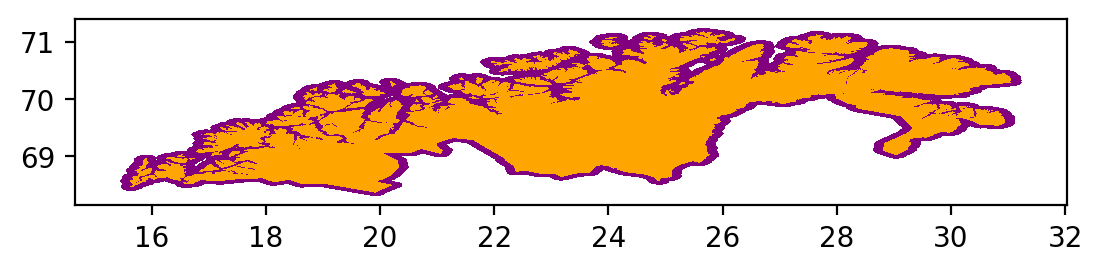

In [71]:
plt.figure(dpi=200)
plot_rle(st_obj.buffered_land_rle, plt.gca(), color="purple")
plot_rle(st_obj.land_rle, plt.gca(), color="orange")

<AxesSubplot:>

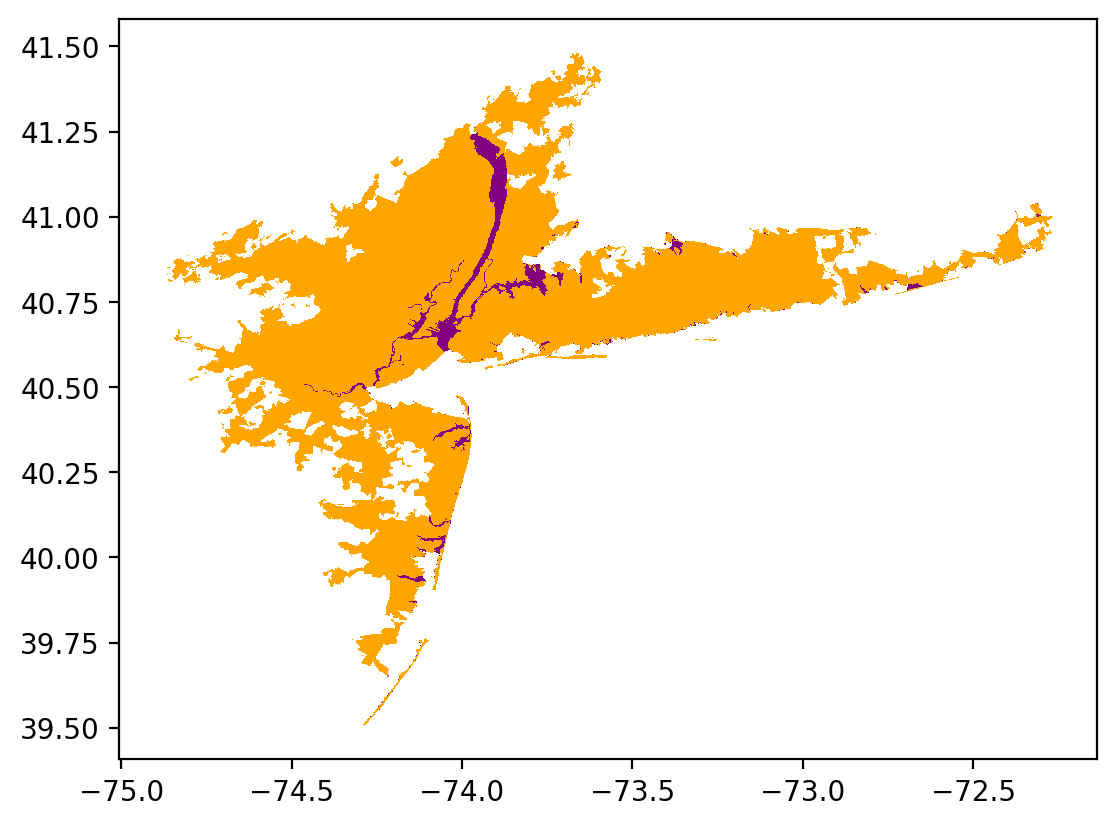

In [51]:
plt.figure(dpi=200)
plot_rle(ur_rle, plt.gca(), color="purple")
plot_rle(ur_rle_land, plt.gca(), color="orange")

<AxesSubplot:>

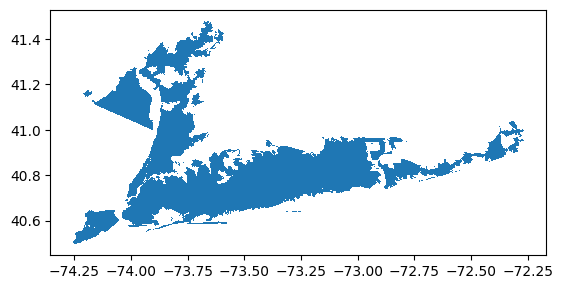

In [61]:
plot_rle(intersect_rle_runs(ur_rle_land, st_rle_land))

/home/kavi/anaconda3/envs/urbanstats-310/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: named_region_shapefiles/World_Administrative_Divisions_processed/subnational_regions.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


compute land RLE summaries:   0%|          | 0/3687 [00:00<?, ?it/s]

buffering with radius (km) 0.8076797735864076
buffering with radius (km) 1.0607854707382287
buffering with radius (km) 1.5687507307390665
buffering with radius (km) 0.22829645894336184


KeyboardInterrupt: 

In [ ]:
x